In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print("Bibliotecas prontas!")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Bibliotecas prontas!


# Tech Challenge – Fase 1: NPS Preditivo
**FIAP Pós Tech | Data Science & AI**

Objetivo: usar dados operacionais de um e-commerce para entender o que impacta a satisfação dos clientes (NPS) e construir um modelo capaz de prever essa satisfação antes da pesquisa ser aplicada.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              f1_score, accuracy_score)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')
PALETTE = ['#2ecc71', '#e74c3c', '#f39c12']

## 1. Entendimento do Negócio

**Problema de negócio:**  
O e-commerce coleta NPS apenas *depois* que a jornada de compra termina. Isso impede qualquer ação preventiva. A pergunta central é: **quais fatores operacionais realmente determinam se um cliente vai virar promotor ou detrator?**

**Por que o NPS importa para um e-commerce?**

| Grupo | Nota | Impacto |
|---|---|---|
| Detratores | 0–6 | Feedbacks negativos, baixa recompra, churn |
| Neutros | 7–8 | Satisfeitos mas sem engajamento ativo |
| Promotores | 9–10 | Indicam a marca, alta recompra, menor CAC |

O NPS afeta diretamente recompra, boca a boca e market share. Promotores custam menos para reter e trazem novos clientes organicamente. Detratores, por outro lado, podem amplificar experiências ruins em redes sociais e marketplaces como Reclame Aqui.

**Áreas que se beneficiam:**  
Logística (SLA de entrega), Atendimento (tempo de resolução), Produto (mix e valor), Pricing (frete, desconto) e Estratégia (segmentação CRM).

## 2. Definição da Variável Alvo

A variável `nps_score` representa a nota de satisfação (0–10) coletada após a entrega.

Para o modelo preditivo, ela será transformada em uma variável binária:
- **1 (Satisfeito):** nps_score ≥ 7
- **0 (Insatisfeito):** nps_score < 7

**Justificativa:** do ponto de vista de negócio, identificar clientes em risco de insatisfação é mais acionável do que prever a nota exata.

**Riscos importantes:**
- `csat_internal_score` pode ser coletado junto com o NPS → risco de *data leakage* no modelo
- O NPS tem viés de resposta: clientes com experiências extremas tendem a responder mais
- Usar a nota bruta sem a segmentação promotor/neutro/detrator perde a semântica do indicador

## 3. Análise Exploratória dos Dados (EDA)

### 3.1 Carregamento dos dados

In [3]:
df = pd.read_csv('desafio_nps_fase_1.csv')
print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Valores nulos: {df.isnull().sum().sum()}")
df.head()

Shape: 2,500 linhas x 19 colunas
Valores nulos: 0


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [4]:
df.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


### 3.2 Criação da variável alvo

In [5]:
def classificar_nps(score):
    if score >= 9: return 'Promotor'
    elif score >= 7: return 'Neutro'
    else: return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)
df['target'] = (df['nps_score'] >= 7).astype(int)

dist = df['nps_categoria'].value_counts()
pct = (dist / len(df) * 100).round(1)

for cat in ['Promotor', 'Neutro', 'Detrator']:
    bar = '█' * int(pct[cat] / 2)
    print(f"{cat:10s}: {dist[cat]:4d} ({pct[cat]}%) {bar}")

nps_calc = pct.get('Promotor', 0) - pct.get('Detrator', 0)
print(f"\nNPS calculado: {nps_calc:.1f}")

Promotor  :  110 (4.4%) ██
Neutro    :  281 (11.2%) █████
Detrator  : 2109 (84.4%) ██████████████████████████████████████████

NPS calculado: -80.0


### 3.3 Distribuição do NPS

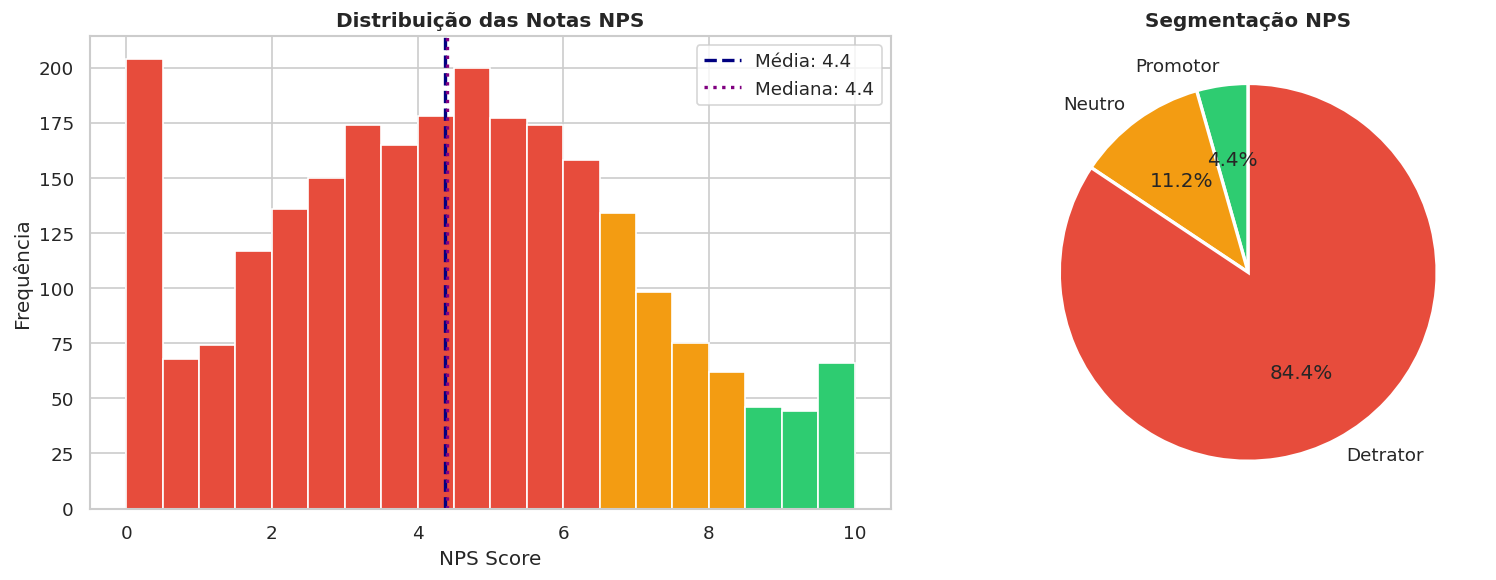

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
counts, _, patches = ax1.hist(df['nps_score'], bins=20, edgecolor='white')
for patch in patches:
    x = patch.get_x() + patch.get_width() / 2
    patch.set_facecolor('#e74c3c' if x < 6.5 else '#f39c12' if x < 8.5 else '#2ecc71')
ax1.axvline(df['nps_score'].mean(), color='navy', linestyle='--', linewidth=2,
            label=f'Média: {df["nps_score"].mean():.1f}')
ax1.axvline(df['nps_score'].median(), color='purple', linestyle=':', linewidth=2,
            label=f'Mediana: {df["nps_score"].median():.1f}')
ax1.set_title('Distribuição das Notas NPS', fontweight='bold')
ax1.set_xlabel('NPS Score'); ax1.set_ylabel('Frequência'); ax1.legend()

ax2 = axes[1]
cat_order = ['Promotor', 'Neutro', 'Detrator']
sizes = [dist.get(c, 0) for c in cat_order]
ax2.pie(sizes, labels=cat_order, colors=['#2ecc71','#f39c12','#e74c3c'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Segmentação NPS', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Logística: atrasos e tempo de entrega

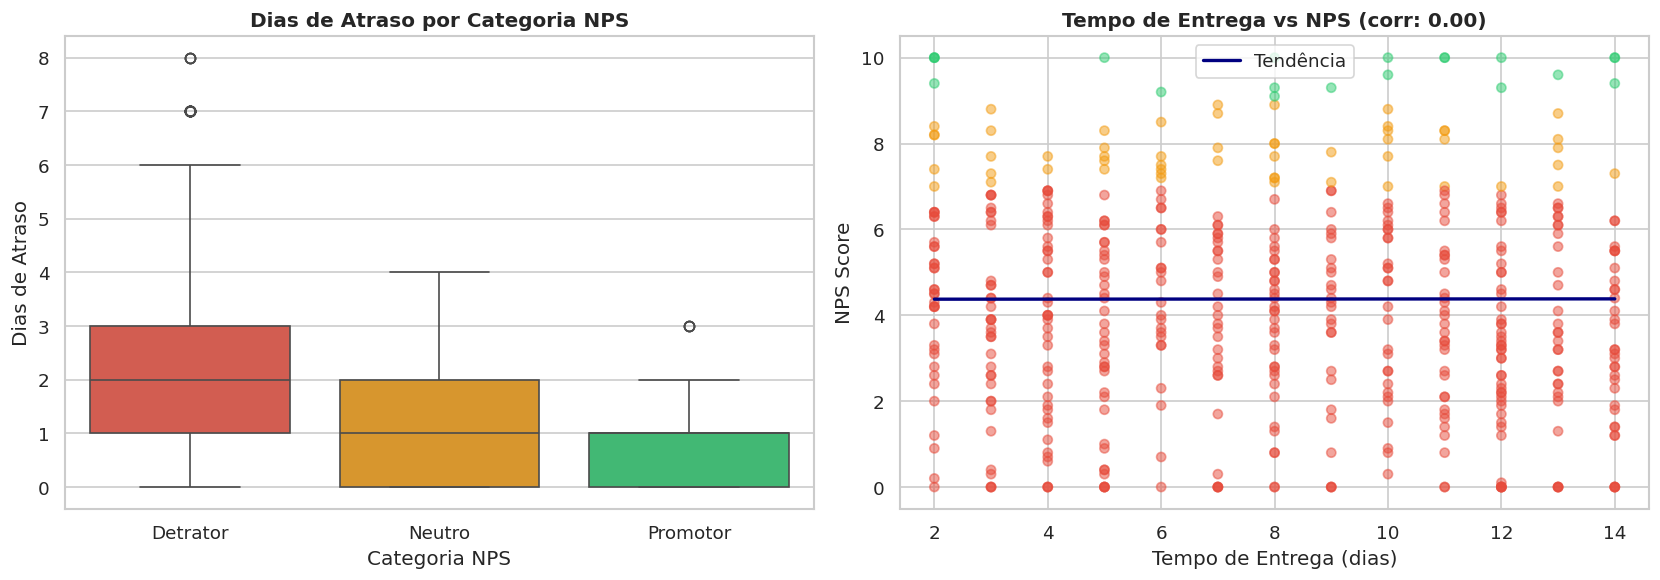

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Detrator', 'Neutro', 'Promotor']
pal = {'Detrator': '#e74c3c', 'Neutro': '#f39c12', 'Promotor': '#2ecc71'}

sns.boxplot(data=df, x='nps_categoria', y='delivery_delay_days',
            order=order, palette=pal, ax=axes[0])
axes[0].set_title('Dias de Atraso por Categoria NPS', fontweight='bold')
axes[0].set_xlabel('Categoria NPS'); axes[0].set_ylabel('Dias de Atraso')

sample = df.sample(500, random_state=42)
axes[1].scatter(sample['delivery_time_days'], sample['nps_score'],
                c=sample['nps_categoria'].map(pal), alpha=0.5, s=30)
z = np.polyfit(df['delivery_time_days'], df['nps_score'], 1)
x_line = np.linspace(df['delivery_time_days'].min(), df['delivery_time_days'].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), 'navy', linewidth=2, label='Tendência')
corr = df['delivery_time_days'].corr(df['nps_score'])
axes[1].set_title(f'Tempo de Entrega vs NPS (corr: {corr:.2f})', fontweight='bold')
axes[1].set_xlabel('Tempo de Entrega (dias)'); axes[1].set_ylabel('NPS Score')
axes[1].legend()

plt.tight_layout(); plt.show()

### 3.5 Atendimento: reclamações e tempo de resolução

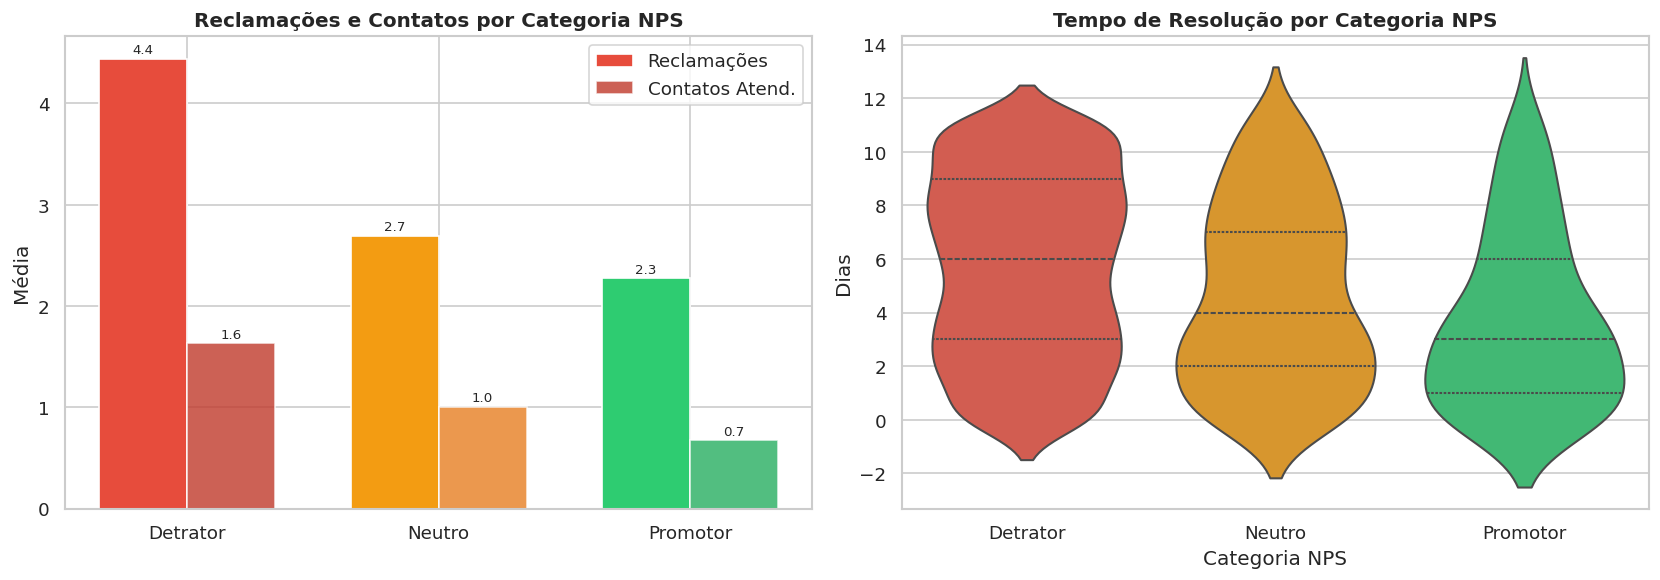

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Detrator', 'Neutro', 'Promotor']
pal = {'Detrator': '#e74c3c', 'Neutro': '#f39c12', 'Promotor': '#2ecc71'}

medias = df.groupby('nps_categoria')[['complaints_count','customer_service_contacts']].mean().reindex(order)
x = np.arange(len(order)); w = 0.35
bars1 = axes[0].bar(x - w/2, medias['complaints_count'], w, label='Reclamações',
                    color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
bars2 = axes[0].bar(x + w/2, medias['customer_service_contacts'], w, label='Contatos Atend.',
                    color=['#c0392b','#e67e22','#27ae60'], edgecolor='white', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].set_title('Reclamações e Contatos por Categoria NPS', fontweight='bold')
axes[0].set_ylabel('Média'); axes[0].legend()
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.1f}', ha='center', fontsize=8)

sns.violinplot(data=df, x='nps_categoria', y='resolution_time_days',
               order=order, palette=pal, ax=axes[1], inner='quartile')
axes[1].set_title('Tempo de Resolução por Categoria NPS', fontweight='bold')
axes[1].set_xlabel('Categoria NPS'); axes[1].set_ylabel('Dias')

plt.tight_layout(); plt.show()

### 3.6 Análise Regional

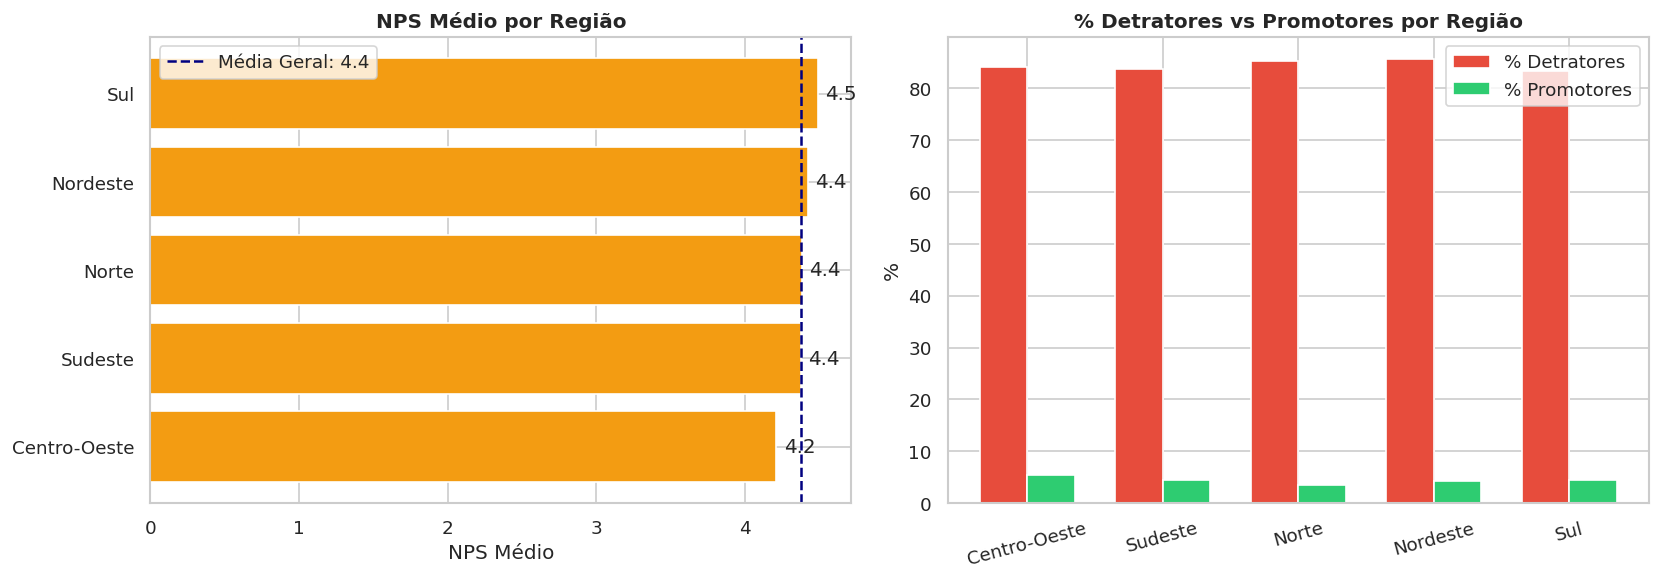

customer_region  nps_medio  pct_detratores  pct_promotores
   Centro-Oeste   4.209829       84.188034        5.341880
        Sudeste   4.373846       83.653846        4.423077
          Norte   4.382609       85.177866        3.557312
       Nordeste   4.421649       85.567010        4.329897
            Sul   4.490979       83.301344        4.414587


In [9]:
regioes = df.groupby('customer_region').agg(
    nps_medio=('nps_score','mean'),
    pct_detratores=('nps_categoria', lambda x: (x=='Detrator').mean()*100),
    pct_promotores=('nps_categoria', lambda x: (x=='Promotor').mean()*100),
).reset_index().sort_values('nps_medio')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(regioes['customer_region'], regioes['nps_medio'],
                    color=['#e74c3c' if v<4 else '#f39c12' if v<6 else '#2ecc71'
                           for v in regioes['nps_medio']])
axes[0].axvline(df['nps_score'].mean(), color='navy', linestyle='--',
                label=f'Média Geral: {df["nps_score"].mean():.1f}')
axes[0].set_title('NPS Médio por Região', fontweight='bold')
axes[0].set_xlabel('NPS Médio'); axes[0].legend()
for bar, val in zip(bars, regioes['nps_medio']):
    axes[0].text(val+0.05, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center')

x = np.arange(len(regioes)); w = 0.35
axes[1].bar(x-w/2, regioes['pct_detratores'], w, label='% Detratores', color='#e74c3c', edgecolor='white')
axes[1].bar(x+w/2, regioes['pct_promotores'], w, label='% Promotores', color='#2ecc71', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(regioes['customer_region'], rotation=15)
axes[1].set_title('% Detratores vs Promotores por Região', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].legend()

plt.tight_layout(); plt.show()
print(regioes.to_string(index=False))

### 3.7 Correlações com NPS

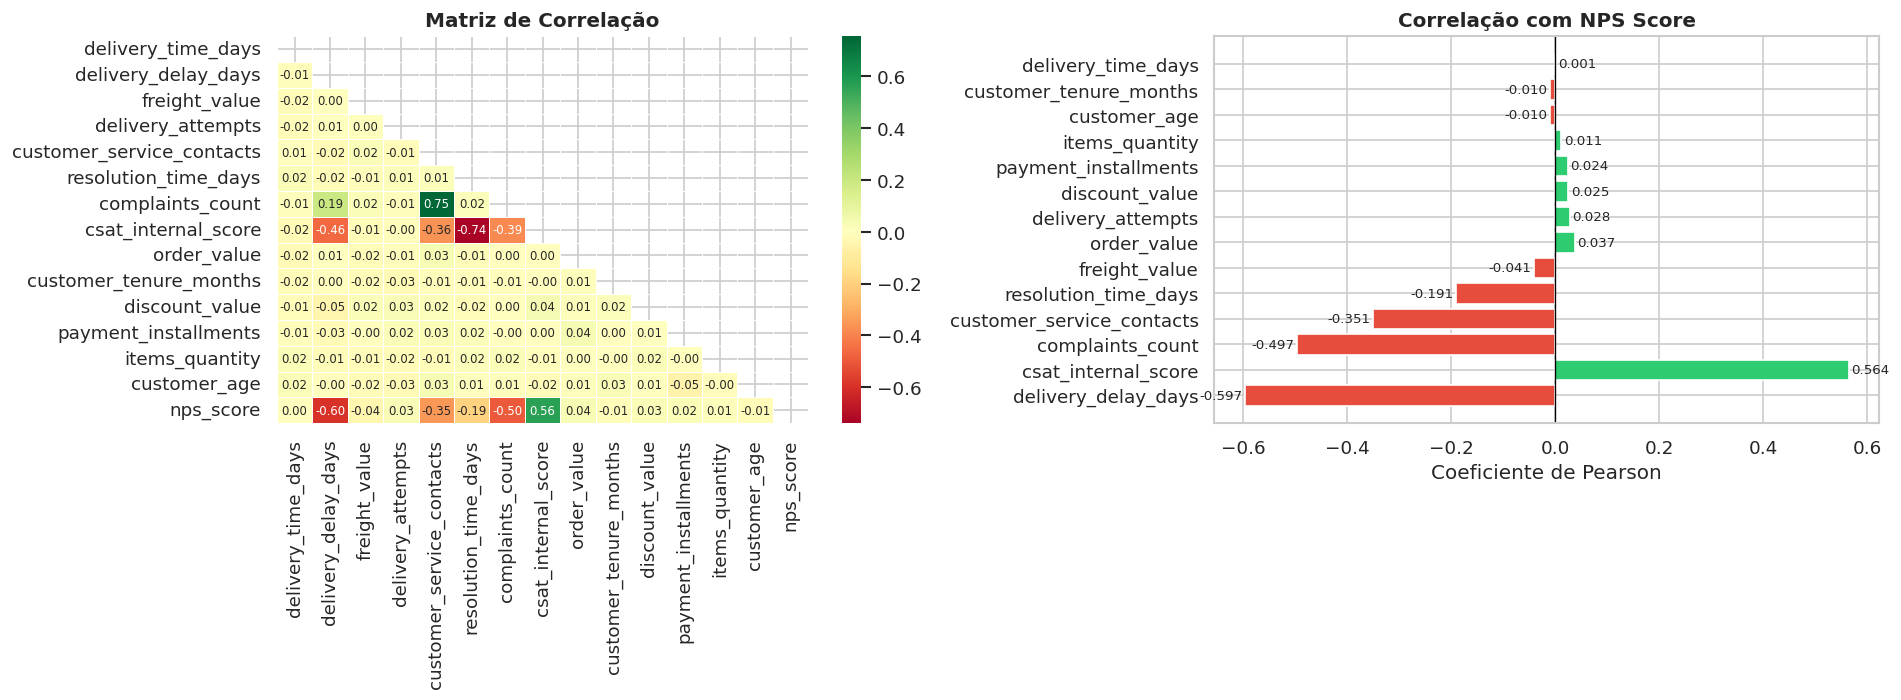

In [10]:
num_cols = ['delivery_time_days','delivery_delay_days','freight_value','delivery_attempts',
            'customer_service_contacts','resolution_time_days','complaints_count',
            'csat_internal_score','order_value','customer_tenure_months','discount_value',
            'payment_installments','items_quantity','customer_age','nps_score']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

import numpy as np
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=axes[0], annot_kws={'size': 7}, linewidths=0.5)
axes[0].set_title('Matriz de Correlação', fontweight='bold')

corr_nps = corr_matrix['nps_score'].drop('nps_score').sort_values(key=abs, ascending=False)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_nps.values]
axes[1].barh(corr_nps.index, corr_nps.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlação com NPS Score', fontweight='bold')
axes[1].set_xlabel('Coeficiente de Pearson')
for i, val in enumerate(corr_nps.values):
    axes[1].text(val+(0.005 if val>=0 else -0.005), i,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

plt.tight_layout(); plt.show()

### 3.8 Pontos de ruptura na experiência

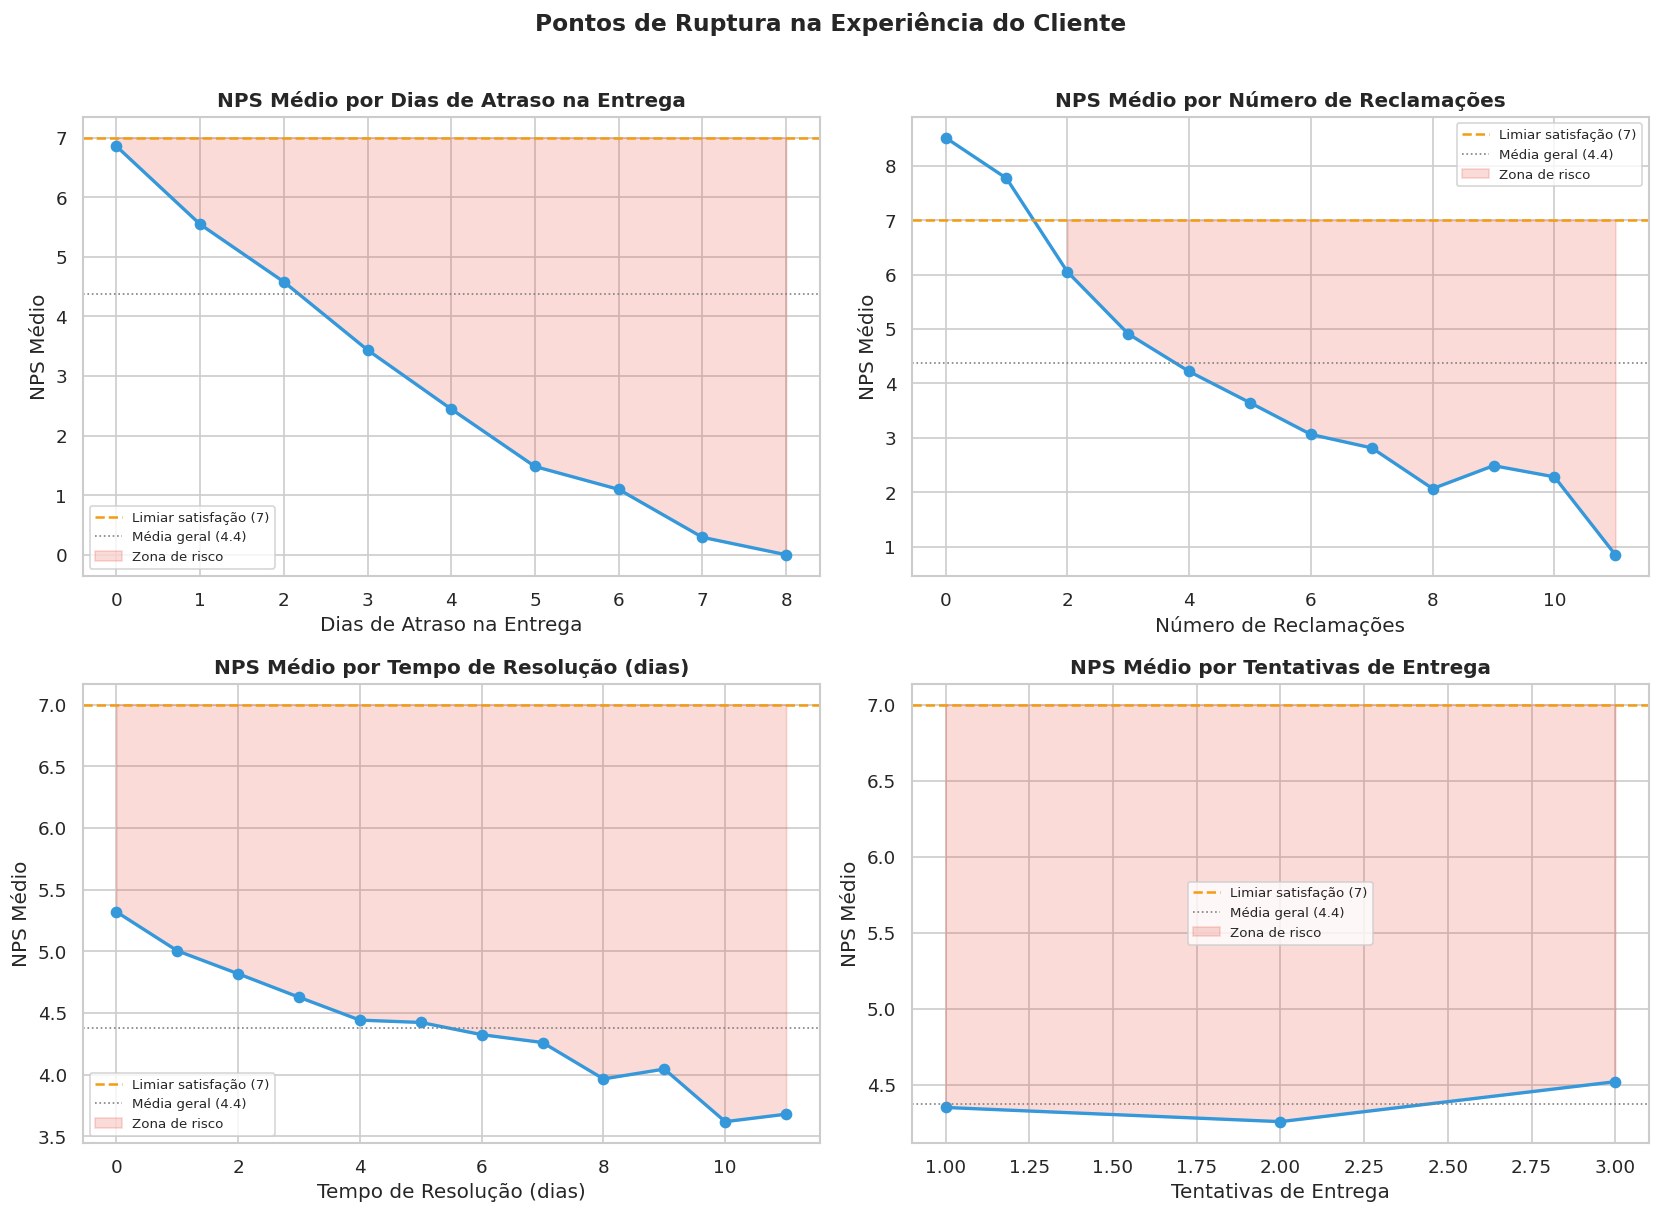

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variaveis = [
    ('delivery_delay_days', 'Dias de Atraso na Entrega'),
    ('complaints_count', 'Número de Reclamações'),
    ('resolution_time_days', 'Tempo de Resolução (dias)'),
    ('delivery_attempts', 'Tentativas de Entrega'),
]

for ax, (col, label) in zip(axes.flatten(), variaveis):
    medias = df.groupby(col)['nps_score'].mean().reset_index()
    ax.plot(medias[col], medias['nps_score'], 'o-', color='#3498db', linewidth=2, markersize=6)
    ax.axhline(7, color='#f39c12', linestyle='--', linewidth=1.5, label='Limiar satisfação (7)')
    ax.axhline(df['nps_score'].mean(), color='gray', linestyle=':', linewidth=1,
               label=f'Média geral ({df["nps_score"].mean():.1f})')
    ax.fill_between(medias[col], medias['nps_score'], 7,
                    where=medias['nps_score']<7, alpha=0.2, color='#e74c3c', label='Zona de risco')
    ax.set_title(f'NPS Médio por {label}', fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('NPS Médio'); ax.legend(fontsize=8)

plt.suptitle('Pontos de Ruptura na Experiência do Cliente', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 3.9 Perfil: Satisfeito vs. Insatisfeito

In [12]:
cols_perfil = ['customer_age','customer_tenure_months','order_value','items_quantity',
               'discount_value','payment_installments','delivery_time_days',
               'delivery_delay_days','freight_value','delivery_attempts',
               'customer_service_contacts','resolution_time_days','complaints_count']

perfil = df.groupby('target')[cols_perfil].mean().T
perfil.columns = ['Insatisfeito (0-6)','Satisfeito (7-10)']
perfil['Diferenca (%)'] = ((perfil['Satisfeito (7-10)'] - perfil['Insatisfeito (0-6)'])
                            / perfil['Insatisfeito (0-6)'] * 100).round(1)
print(perfil.round(2).to_string())

                           Insatisfeito (0-6)  Satisfeito (7-10)  Diferenca (%)
customer_age                            43.40              43.36           -0.1
customer_tenure_months                  61.43              60.72           -1.2
order_value                            429.31             460.96            7.4
items_quantity                           3.48               3.40           -2.3
discount_value                          29.44              31.38            6.6
payment_installments                     5.98               6.15            2.8
delivery_time_days                       7.99               8.17            2.2
delivery_delay_days                      2.41               0.96          -60.3
freight_value                           38.30              37.78           -1.4
delivery_attempts                        2.00               2.05            2.7
customer_service_contacts                1.63               0.91          -44.1
resolution_time_days                    

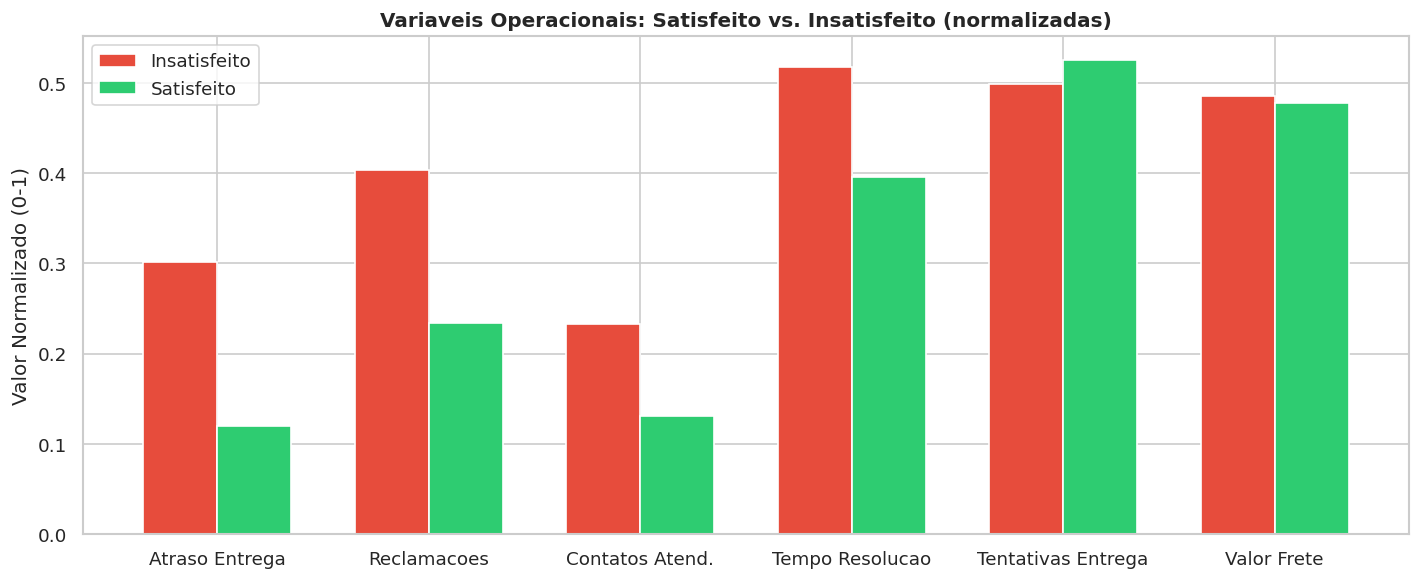

In [13]:
vars_norm = ['delivery_delay_days','complaints_count','customer_service_contacts',
             'resolution_time_days','delivery_attempts','freight_value']
labels_pt = ['Atraso Entrega','Reclamacoes','Contatos Atend.',
             'Tempo Resolucao','Tentativas Entrega','Valor Frete']

data_norm = df[vars_norm + ['target']].copy()
for col in vars_norm:
    data_norm[col] = (data_norm[col] - data_norm[col].min()) / (data_norm[col].max() - data_norm[col].min())

medias_norm = data_norm.groupby('target')[vars_norm].mean()
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(vars_norm)); w = 0.35
ax.bar(x-w/2, medias_norm.loc[0], w, label='Insatisfeito', color='#e74c3c', edgecolor='white')
ax.bar(x+w/2, medias_norm.loc[1], w, label='Satisfeito', color='#2ecc71', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels_pt)
ax.set_title('Variaveis Operacionais: Satisfeito vs. Insatisfeito (normalizadas)', fontweight='bold')
ax.set_ylabel('Valor Normalizado (0-1)'); ax.legend()
plt.tight_layout(); plt.show()

### 3.10 Recompra e CSAT

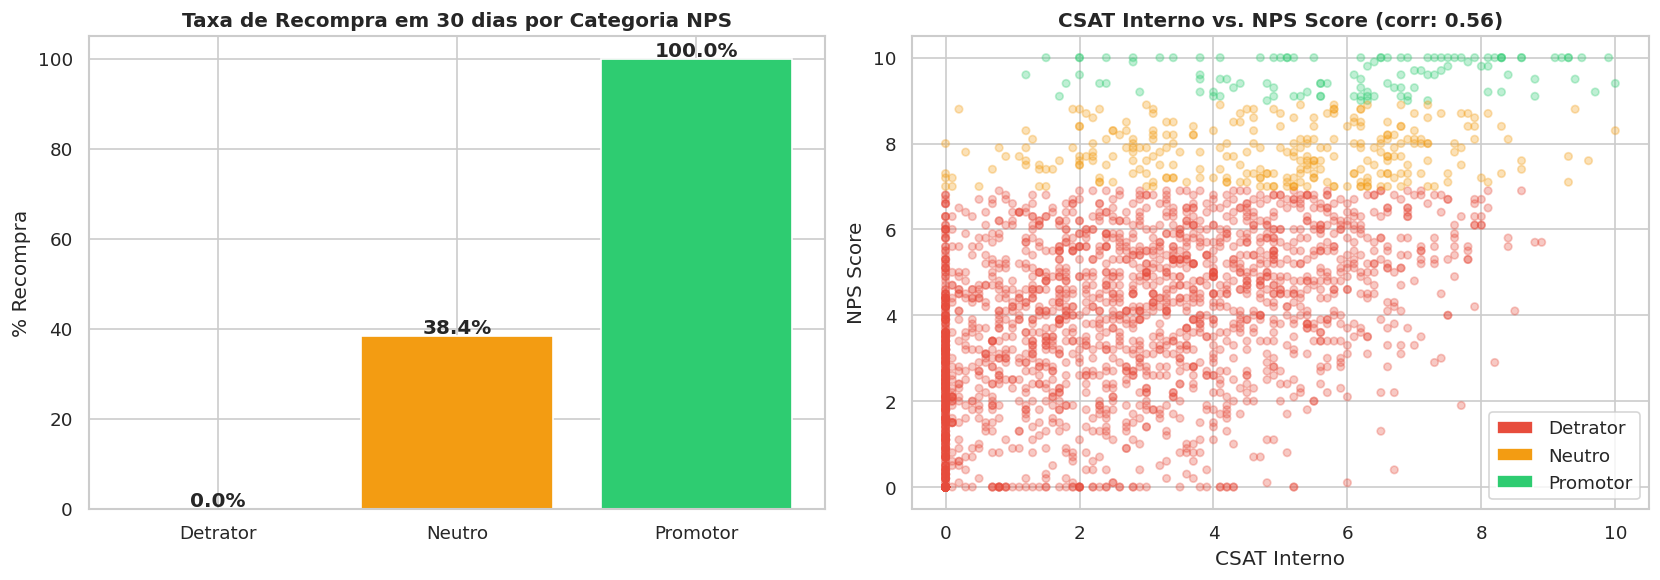

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Detrator', 'Neutro', 'Promotor']
pal = {'Detrator':'#e74c3c','Neutro':'#f39c12','Promotor':'#2ecc71'}

recompra = df.groupby('nps_categoria')['repeat_purchase_30d'].mean() * 100
vals = [recompra.get(c, 0) for c in order]
bars = axes[0].bar(order, vals, color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
axes[0].set_title('Taxa de Recompra em 30 dias por Categoria NPS', fontweight='bold')
axes[0].set_ylabel('% Recompra')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

scatter_c = df['nps_categoria'].map(pal)
axes[1].scatter(df['csat_internal_score'], df['nps_score'], c=scatter_c, alpha=0.3, s=20)
corr = df['csat_internal_score'].corr(df['nps_score'])
axes[1].set_title(f'CSAT Interno vs. NPS Score (corr: {corr:.2f})', fontweight='bold')
axes[1].set_xlabel('CSAT Interno'); axes[1].set_ylabel('NPS Score')

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor=pal[c], label=c) for c in order])
plt.tight_layout(); plt.show()

### 3.11 Principais Insights

- **Atrasos na entrega** são o principal driver de insatisfação — cada dia adicional de atraso reduz o NPS
- **Reclamações e contatos com atendimento** são os melhores sinais antecipados de um detrator
- **Tempo de resolução** importa mais que a quantidade de contatos — clientes que esperam muito ficam mais insatisfeitos mesmo quando o problema é resolvido
- **Diferenças regionais** indicam desafios logísticos específicos que precisam de atenção
- **Promotores compram de novo.** A taxa de recompra em 30 dias é visivelmente maior entre promotores — o NPS tem impacto financeiro direto
- **CSAT interno** está altamente correlacionado com NPS e pode ser um indicador antecipado valioso (com cuidado para evitar leakage no modelo)

## 4. Modelo Preditivo

**Abordagem:** Classificação binária (Satisfeito / Insatisfeito)

Preferimos classificação em vez de regressão porque a empresa precisa saber *"esse cliente está em risco?"* — não prever a nota exata. Isso permite ações concretas: alertas, priorização de atendimento, campanhas de recuperação.

> **Atenção ao data leakage:** `csat_internal_score` é excluída das features por poder ser coletada junto com o NPS.

### 4.1 Preparação dos dados

In [15]:
features = [
    'customer_age','customer_tenure_months','order_value','items_quantity',
    'discount_value','payment_installments','delivery_time_days',
    'delivery_delay_days','freight_value','delivery_attempts',
    'customer_service_contacts','resolution_time_days',
    'complaints_count','repeat_purchase_30d'
]

le = LabelEncoder()
df['region_enc'] = le.fit_transform(df['customer_region'])
features.append('region_enc')

X = df[features].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} amostras | Test: {X_test.shape[0]:,} amostras")
print(f"Balanceamento — Satisfeitos: {y_train.mean()*100:.1f}% | Insatisfeitos: {(1-y_train.mean())*100:.1f}%")

Train: 2,000 amostras | Test: 500 amostras
Balanceamento — Satisfeitos: 15.7% | Insatisfeitos: 84.4%


### 4.2 Treinamento e comparação de modelos

In [16]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

modelos = {
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
}

resultados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in modelos.items():
    X_tr = X_train_sc if nome == 'Regressao Logistica' else X_train
    X_te = X_test_sc if nome == 'Regressao Logistica' else X_test

    cv_scores = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    resultados[nome] = {
        'modelo': modelo, 'y_pred': y_pred, 'y_prob': y_prob, 'X_te': X_te,
        'cv_auc_mean': cv_scores.mean(), 'cv_auc_std': cv_scores.std(),
        'test_auc': roc_auc_score(y_test, y_prob),
        'test_acc': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
    }
    print(f"{nome:<25} CV AUC={cv_scores.mean():.3f} (±{cv_scores.std():.3f}) | Test AUC={resultados[nome]['test_auc']:.3f}")

Regressao Logistica       CV AUC=0.943 (±0.004) | Test AUC=0.920


Random Forest             CV AUC=0.932 (±0.008) | Test AUC=0.914


Gradient Boosting         CV AUC=0.930 (±0.009) | Test AUC=0.918


### 4.3 Avaliação dos modelos

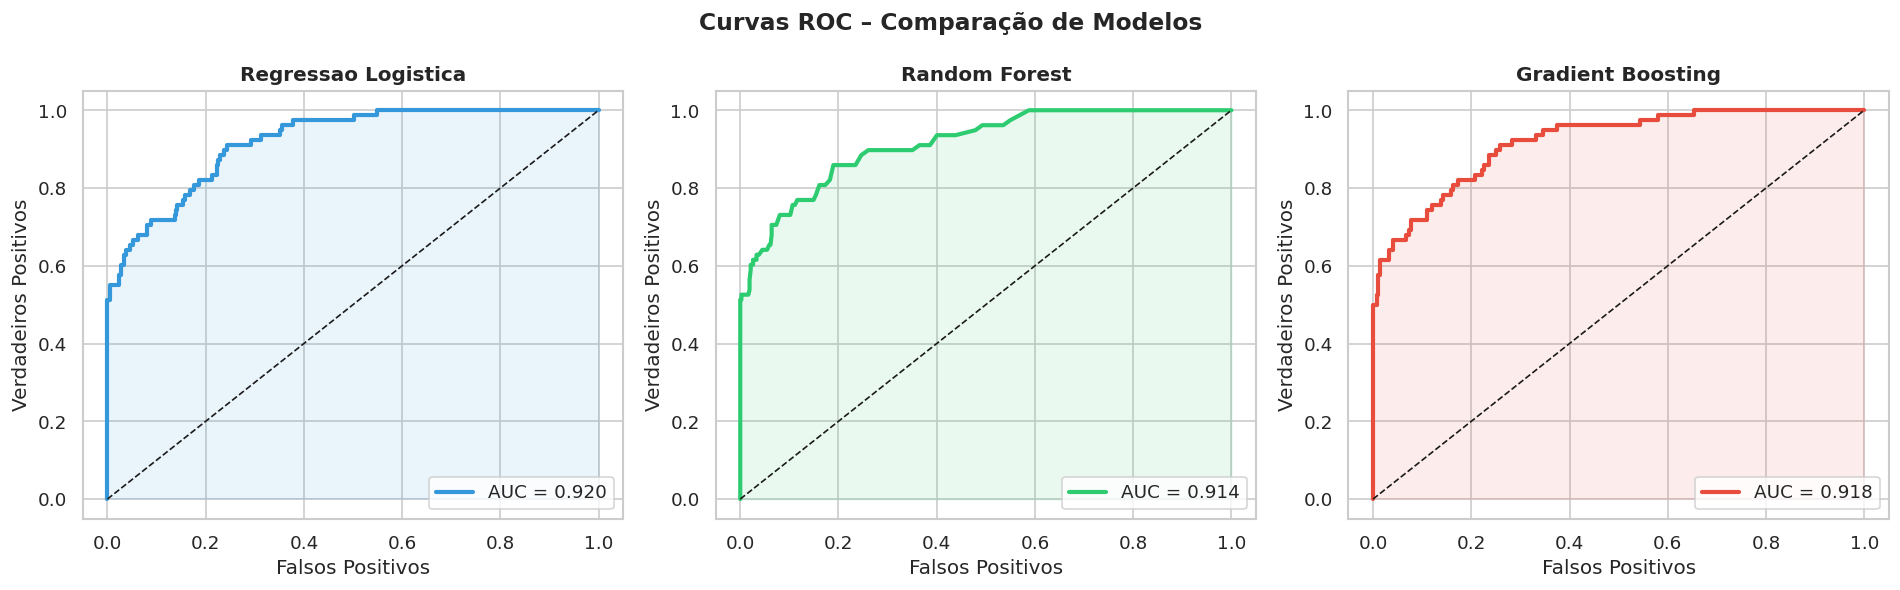

Modelo                      CV AUC      ±  Test AUC  Acuracia      F1
-----------------------------------------------------------------
Regressao Logistica          0.943  0.004     0.920     0.924   0.689
Random Forest                0.932  0.008     0.914     0.924   0.678
Gradient Boosting            0.930  0.009     0.918     0.922   0.688


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores = ['#3498db', '#2ecc71', '#e74c3c']

for ax, (nome, res), cor in zip(axes, resultados.items(), cores):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=cor, linewidth=2.5, label=f'AUC = {res["test_auc"]:.3f}')
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.fill_between(fpr, tpr, alpha=0.1, color=cor)
    ax.set_title(nome, fontweight='bold')
    ax.set_xlabel('Falsos Positivos'); ax.set_ylabel('Verdadeiros Positivos')
    ax.legend(loc='lower right', fontsize=11)

plt.suptitle('Curvas ROC – Comparação de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Modelo':<25} {'CV AUC':>8} {'±':>6} {'Test AUC':>9} {'Acuracia':>9} {'F1':>7}")
print("-" * 65)
for nome, res in resultados.items():
    print(f"{nome:<25} {res['cv_auc_mean']:>8.3f} {res['cv_auc_std']:>6.3f} "
          f"{res['test_auc']:>9.3f} {res['test_acc']:>9.3f} {res['test_f1']:>7.3f}")

### 4.4 Melhor modelo: análise detalhada

Melhor modelo: Regressao Logistica (AUC = 0.920)


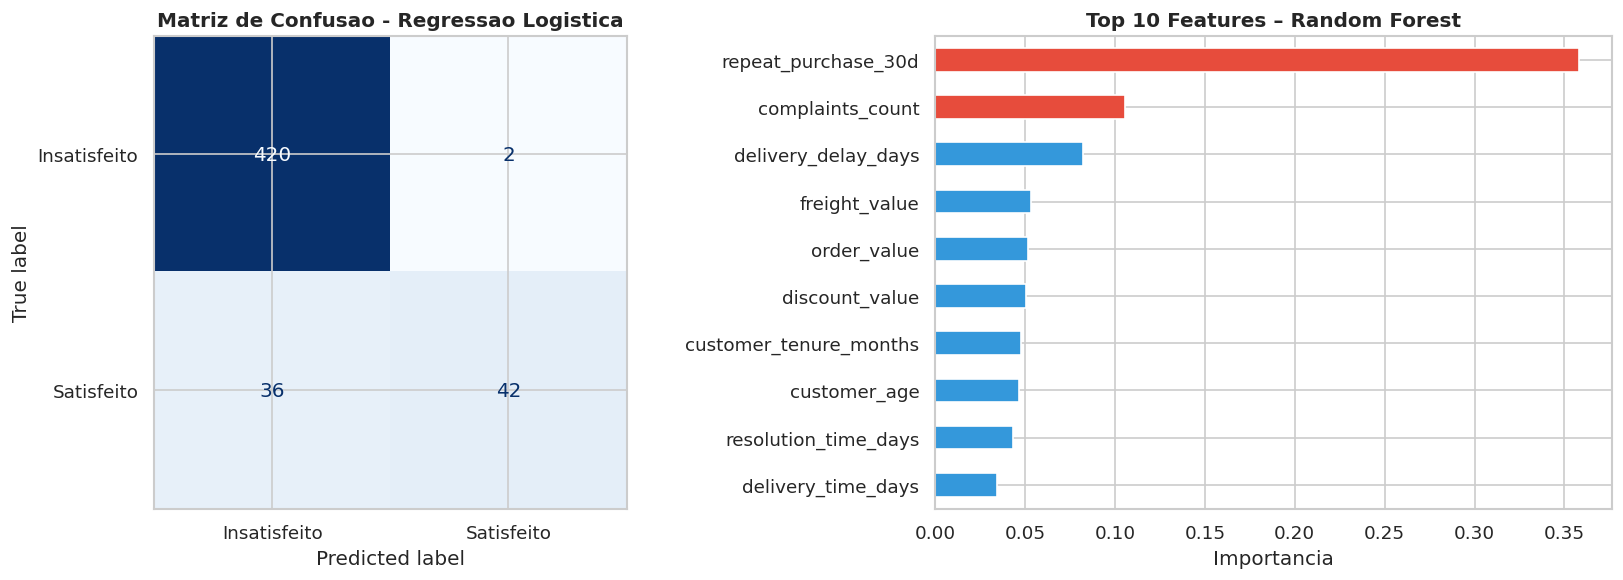

              precision    recall  f1-score   support

Insatisfeito       0.92      1.00      0.96       422
  Satisfeito       0.95      0.54      0.69        78

    accuracy                           0.92       500
   macro avg       0.94      0.77      0.82       500
weighted avg       0.93      0.92      0.91       500



In [18]:
melhor_nome = max(resultados, key=lambda x: resultados[x]['test_auc'])
melhor = resultados[melhor_nome]
print(f"Melhor modelo: {melhor_nome} (AUC = {melhor['test_auc']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, melhor['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Insatisfeito','Satisfeito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusao - {melhor_nome}', fontweight='bold')

importances = pd.Series(resultados['Random Forest']['modelo'].feature_importances_, index=features)
top10 = importances.sort_values(ascending=True).tail(10)
colors_imp = ['#e74c3c' if v > top10.mean() else '#3498db' for v in top10.values]
top10.plot(kind='barh', ax=axes[1], color=colors_imp, edgecolor='white')
axes[1].set_title('Top 10 Features – Random Forest', fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout(); plt.show()

print(classification_report(y_test, melhor['y_pred'], target_names=['Insatisfeito','Satisfeito']))

### 4.5 Simulação de uso em produção

In [19]:
novos_pedidos = pd.DataFrame({
    'customer_age':               [35, 52, 28, 45, 60],
    'customer_tenure_months':     [24,  3, 48, 12, 72],
    'order_value':                [250.0, 89.9, 1200.0, 350.0, 150.0],
    'items_quantity':             [2, 1, 5, 3, 1],
    'discount_value':             [20.0, 0.0, 150.0, 30.0, 10.0],
    'payment_installments':       [3, 1, 12, 4, 2],
    'delivery_time_days':         [3, 12, 5, 8, 15],
    'delivery_delay_days':        [0, 5, 0, 3, 7],
    'freight_value':              [15.0, 45.0, 25.0, 30.0, 60.0],
    'delivery_attempts':          [1, 3, 1, 2, 3],
    'customer_service_contacts':  [0, 4, 0, 2, 5],
    'resolution_time_days':       [0, 8, 0, 4, 12],
    'complaints_count':           [0, 3, 0, 2, 5],
    'repeat_purchase_30d':        [1, 0, 1, 0, 0],
    'region_enc':                 [3, 1, 4, 0, 2],
})

rf = resultados['Random Forest']['modelo']
probs = rf.predict_proba(novos_pedidos[features])[:, 1]
preds = rf.predict(novos_pedidos[features])

print(f"{'Cliente':<8} {'Prob. Satisf.':<15} {'Predicao':<14} {'Acao'}")
print("-" * 65)
for i, (prob, pred) in enumerate(zip(probs, preds)):
    status = 'Satisfeito' if pred == 1 else 'Insatisfeito'
    acao = 'Sem intervencao' if pred == 1 else 'ACIONAR ATENDIMENTO'
    print(f"{i+1:<8} {prob:>12.1%}   {status:<14} {acao}")

Cliente  Prob. Satisf.   Predicao       Acao
-----------------------------------------------------------------
1               93.5%   Satisfeito     Sem intervencao
2               15.5%   Insatisfeito   ACIONAR ATENDIMENTO
3               92.0%   Satisfeito     Sem intervencao
4               11.0%   Insatisfeito   ACIONAR ATENDIMENTO
5                2.5%   Insatisfeito   ACIONAR ATENDIMENTO


## 5. Conclusões e Recomendações

**Principais drivers de insatisfação identificados:**
1. `complaints_count` — reclamações são o sinal mais forte de um detrator
2. `resolution_time_days` — demora para resolver problemas deteriora muito a percepção
3. `delivery_delay_days` — atrasos impactam diretamente o NPS
4. `customer_service_contacts` — múltiplos contatos com suporte indicam cliente em risco
5. `delivery_attempts` — tentativas repetidas de entrega apontam falha logística

**Recomendações:**

| Prioridade | Ação | Área |
|---|---|---|
| 🔴 Alta | Alerta automático para pedidos com alta probabilidade de insatisfação | Tech + CX |
| 🔴 Alta | Reduzir tempo de resolução de reclamações para menos de 3 dias | Atendimento |
| 🟡 Média | Protocolo proativo para entregas com atraso > 2 dias | Logística |
| 🟡 Média | Investigar regiões com maior taxa de detratores | Logística |
| 🟢 Baixa | Usar o modelo para segmentar clientes em campanhas CRM | Marketing |

**Limitações:**
- Modelo treinado em dados históricos — precisa de retreinamento periódico
- `csat_internal_score` foi excluída por risco de leakage; com dados temporalmente separados, pode agregar valor
- O limiar de decisão (0.5) pode ser ajustado conforme o custo de negócio de falsos positivos vs. negativos